# ORACLE — Medical Jargon Identifier
## Stage 3: Jargon Identification and Frequency Analysis

**Purpose:** Scan full 37,076-record ORACLE corpus to identify medical jargon candidates
for expanding the literacy_adapter.py substitution table.

**Current substitution table:** 38 terms in literacy_adapter.py
**Terms identified:** 1,491 unique medical terms across corpus
**Candidates (freq ≥ 5):** 569 terms ranked by jargon score

**Jargon score:** (clinical+high frequency) - (low+medium frequency) / total
Higher score = term appears in clinical docs but not plain language = stronger candidate

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
from IPython.display import Image
from jargon_identifier import run_jargon_identifier
print('Imports complete')

Imports complete


In [2]:
import os
os.chdir('..')  # move to repo root
candidates_df = run_jargon_identifier()
os.chdir('notebooks')
print('Jargon identification complete')

ORACLE Phase 4 — Stage 3: Medical Jargon Identifier

--- Loading Corpus ---


  Records: 37,076 across 6 sources
  Literacy bands: {'medium': 14829, 'high': 12448, 'clinical': 5535, 'low': 4264}

--- Extracting Medical Terms ---


  Records with medical terms: 17,905

--- Computing Term Frequencies ---


  Unique medical terms found: 1,491
  Top 10 by frequency:
    diagnosis                      3,193
    analysis                       1,230
    biopsy                         1,197
    carcinoma                      1,071
    edema                          883
    diarrhea                       736
    anemia                         487
    infarction                     411
    hepatitis                      406
    urinalysis                     399

  Top 10 jargon candidates (highest clinical/high vs low/medium gap):
    neurotoxicity                  score=0.938 total=15 clinical=8 low=0
    adenosis                       score=0.889 total=8 clinical=2 low=0
    hyperphenylalaninemia          score=0.875 total=7 clinical=3 low=0
    cystourethrography             score=0.857 total=6 clinical=1 low=0
    glycemia                       score=0.857 total=6 clinical=4 low=0
    neurosis                       score=0.857 total=6 clinical=3 low=0
    ketosis                        scor

  Fig 2 saved -- jargon_band_heatmap.png
  Fig 3 saved -- jargon_score_distribution.png


  Fig 4 saved -- jargon_source_distribution.png
  Fig 5 saved -- jargon_fk_vs_jargon_scatter.png

--- Jargon Identifier complete ---
  1,491 unique medical terms identified in corpus
  569 candidates with frequency >= 5
  Top 50 saved to jargon_candidates.csv
  5 figures saved to figures/stage3/
  Existing 38-term substitution table excluded from candidates
  Top candidates should be reviewed for addition to literacy_adapter.py
Jargon identification complete


## 1. Top 20 Jargon Candidates by Frequency

Top 20 medical terms by jargon score — terms that appear predominantly in clinical/high
literacy bands but rarely in low/medium bands. Strongest candidates for expansion
of the literacy_adapter.py JARGON_SUBSTITUTIONS table.
Red = high jargon score (>0.5), Orange = medium (>0.2), Blue = lower.

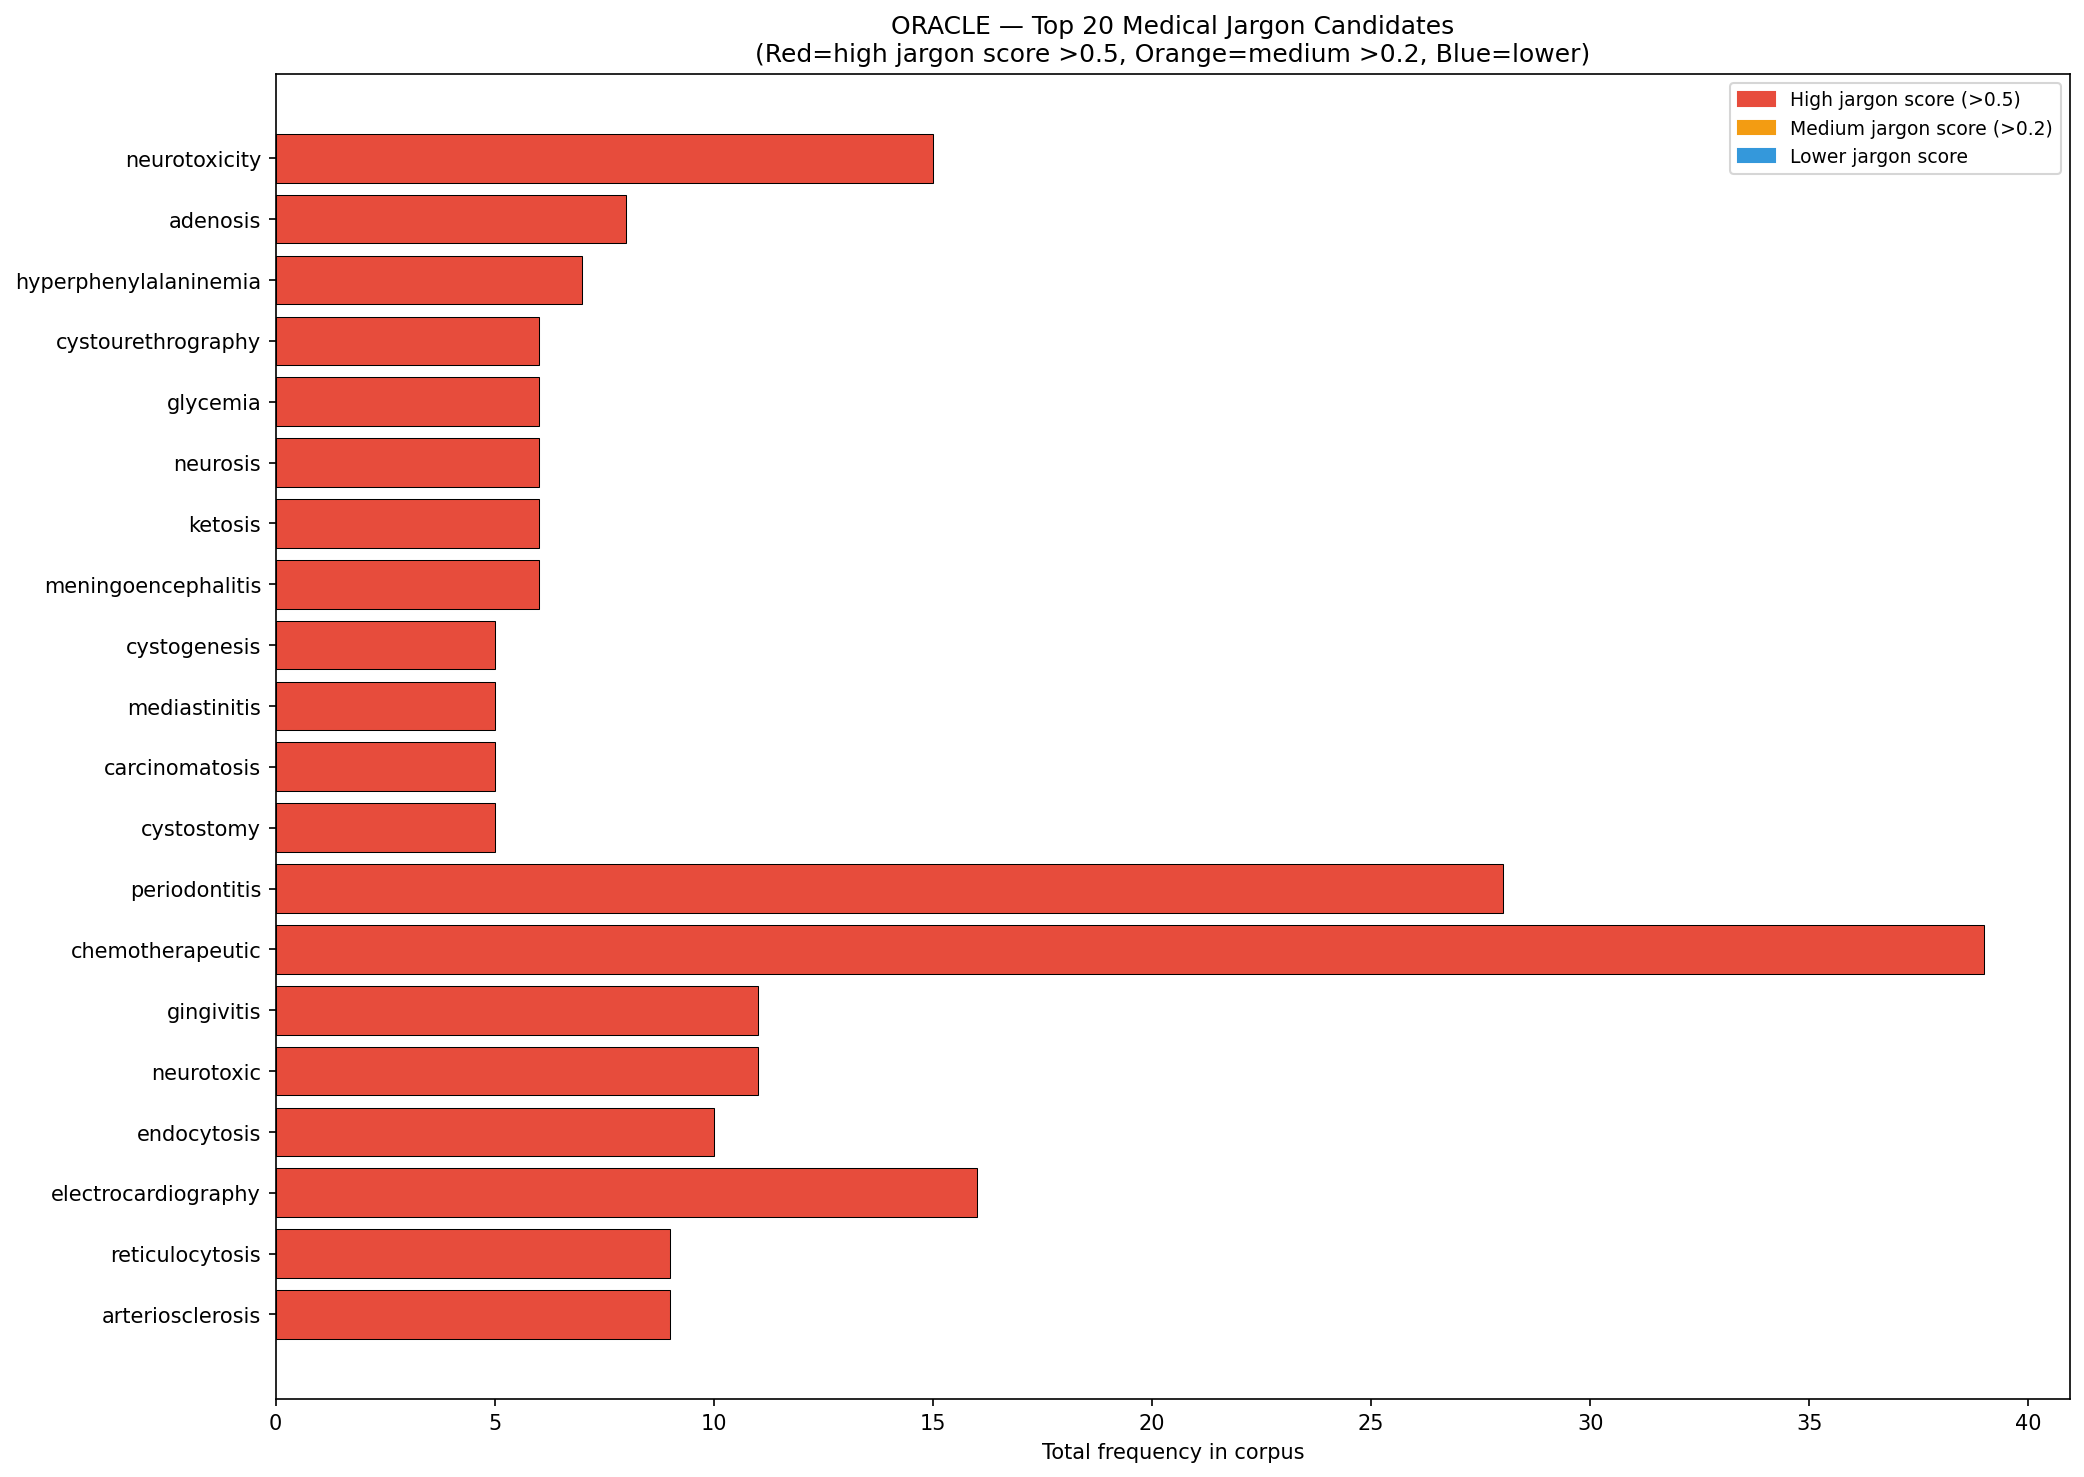

In [3]:
Image('../figures/stage3/jargon_top20_candidates.png')

## 2. Jargon Frequency by Literacy Band — Heatmap

Term frequency breakdown across clinical, high, medium, low literacy bands
for the top 20 candidates. Confirms jargon score — terms with high
clinical/high counts and zero low counts are strongest substitution candidates.

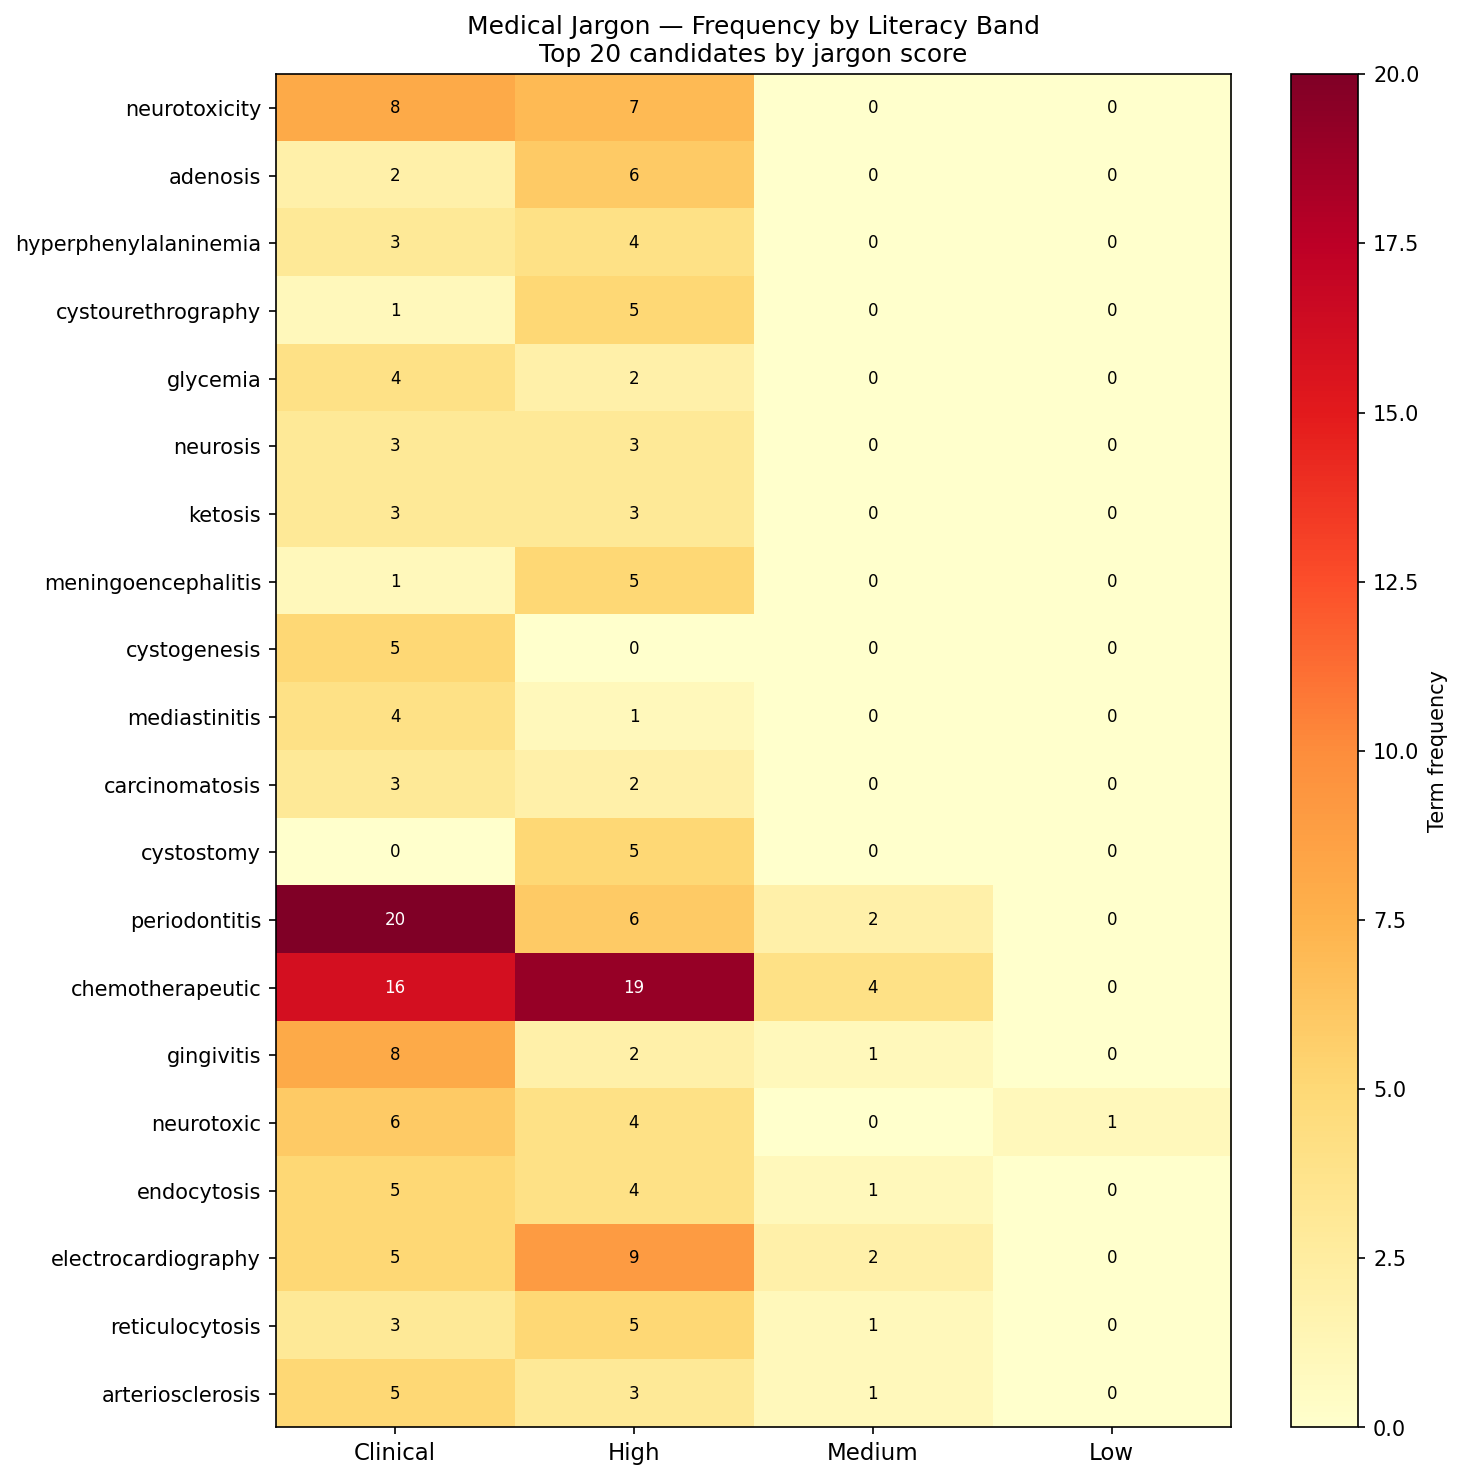

In [4]:
Image('../figures/stage3/jargon_band_heatmap.png')

## 3. Jargon Score Distribution

Distribution of jargon scores across all 569 candidates (frequency ≥ 5).
Most terms cluster below 0.2 — used across all literacy bands.
High-score terms (>0.5) are the most promising substitution candidates.

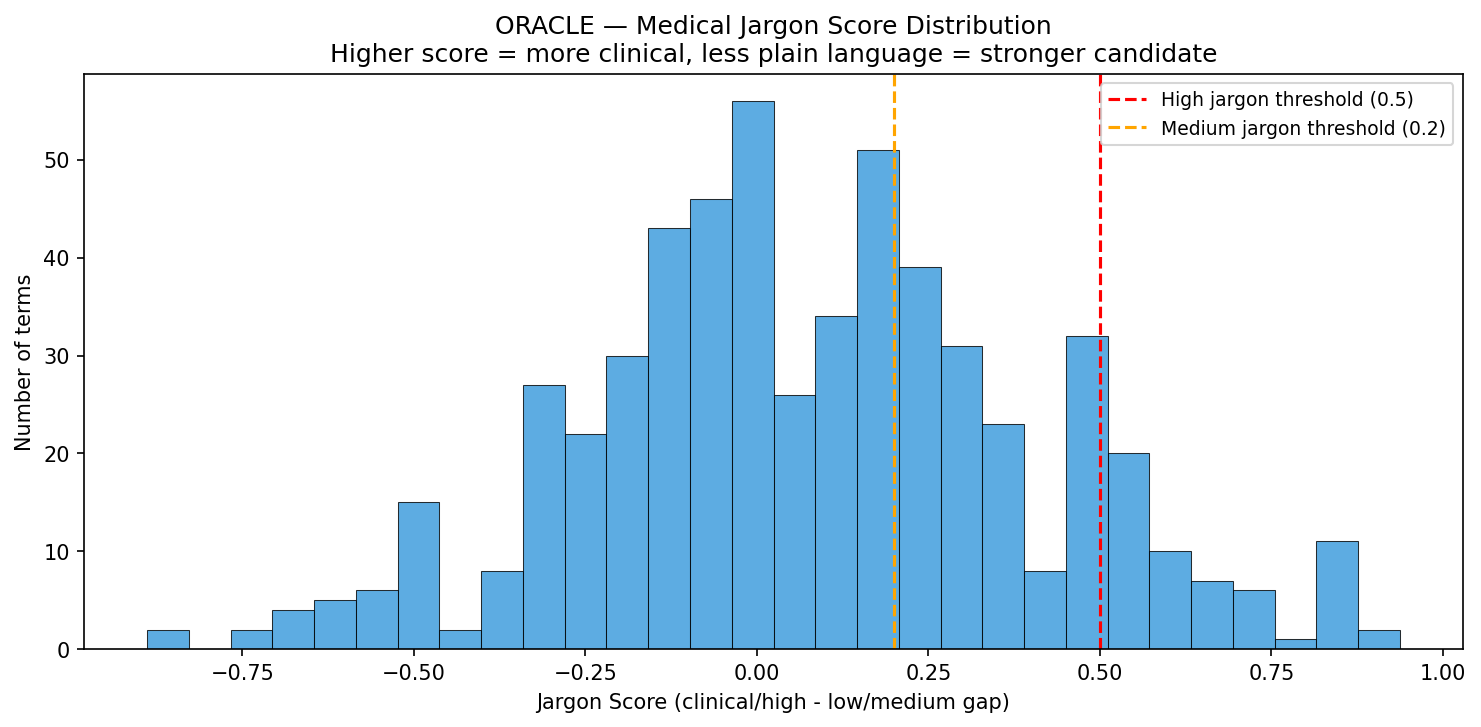

In [5]:
Image('../figures/stage3/jargon_score_distribution.png')

## 4. Jargon Distribution by Source

Mean and total jargon terms per record by corpus source.
PLABA (plain language) expected to show lowest jargon density —
validates corpus design and FK proxy failure finding.

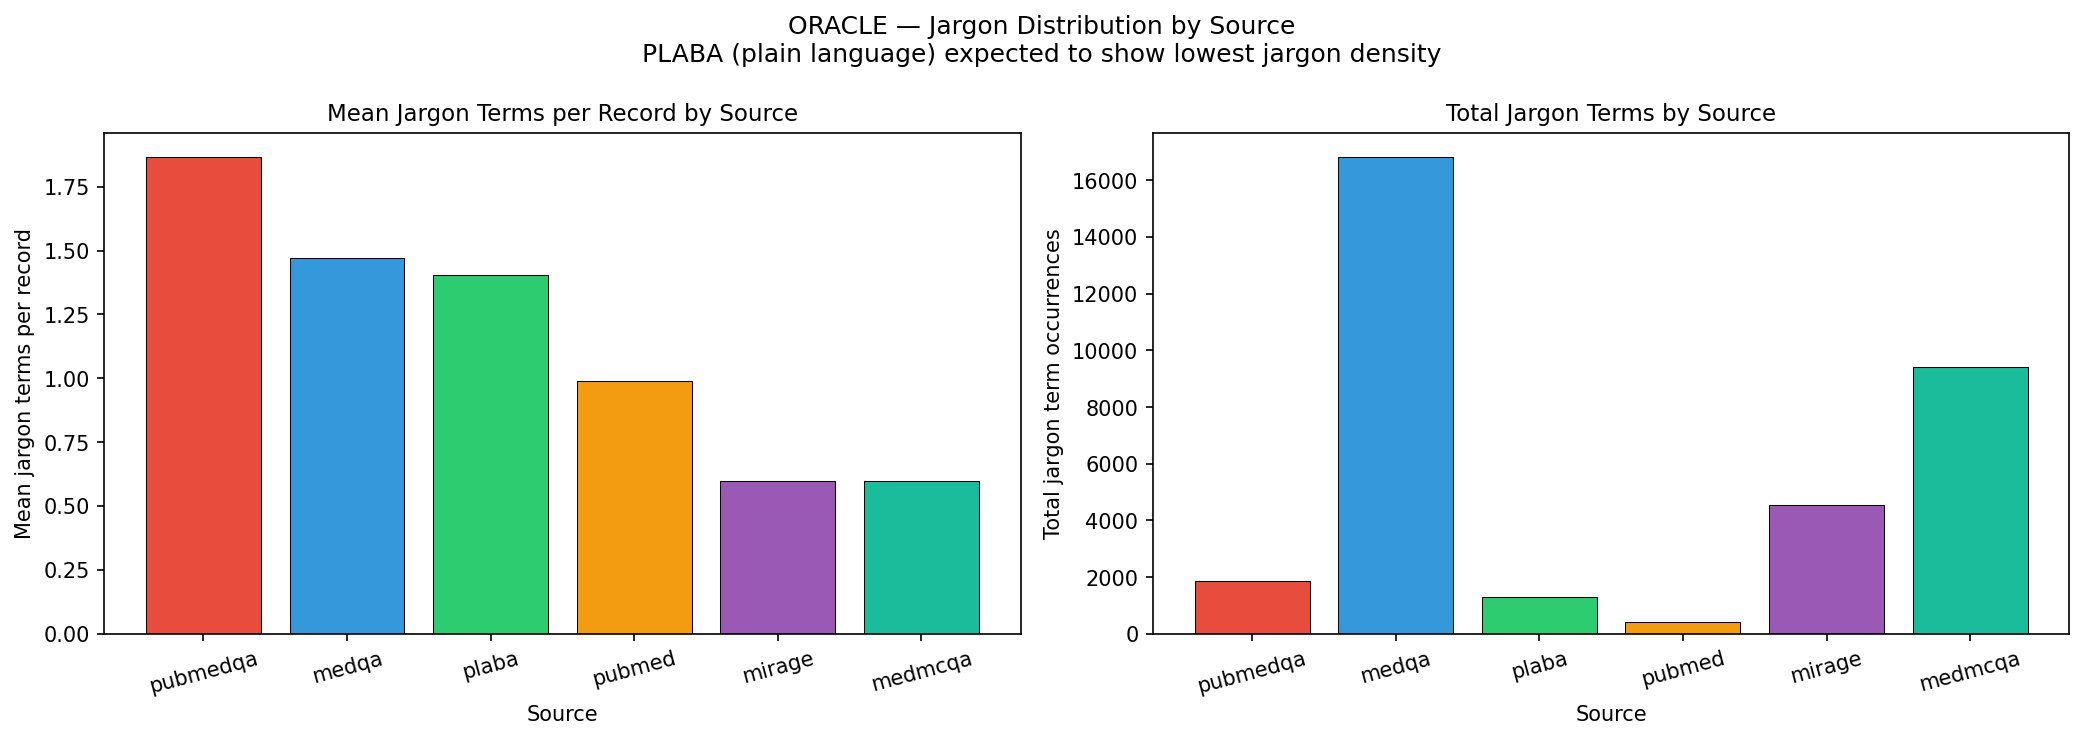

In [6]:
Image('../figures/stage3/jargon_source_distribution.png')

## 5. FK Grade vs Jargon Density Scatter

Mean FK grade vs mean jargon terms per record by source.
Key finding: PLABA has low FK but non-zero jargon density — confirms FK measures
sentence length, not vocabulary difficulty. FK is a poor proxy for medical jargon.

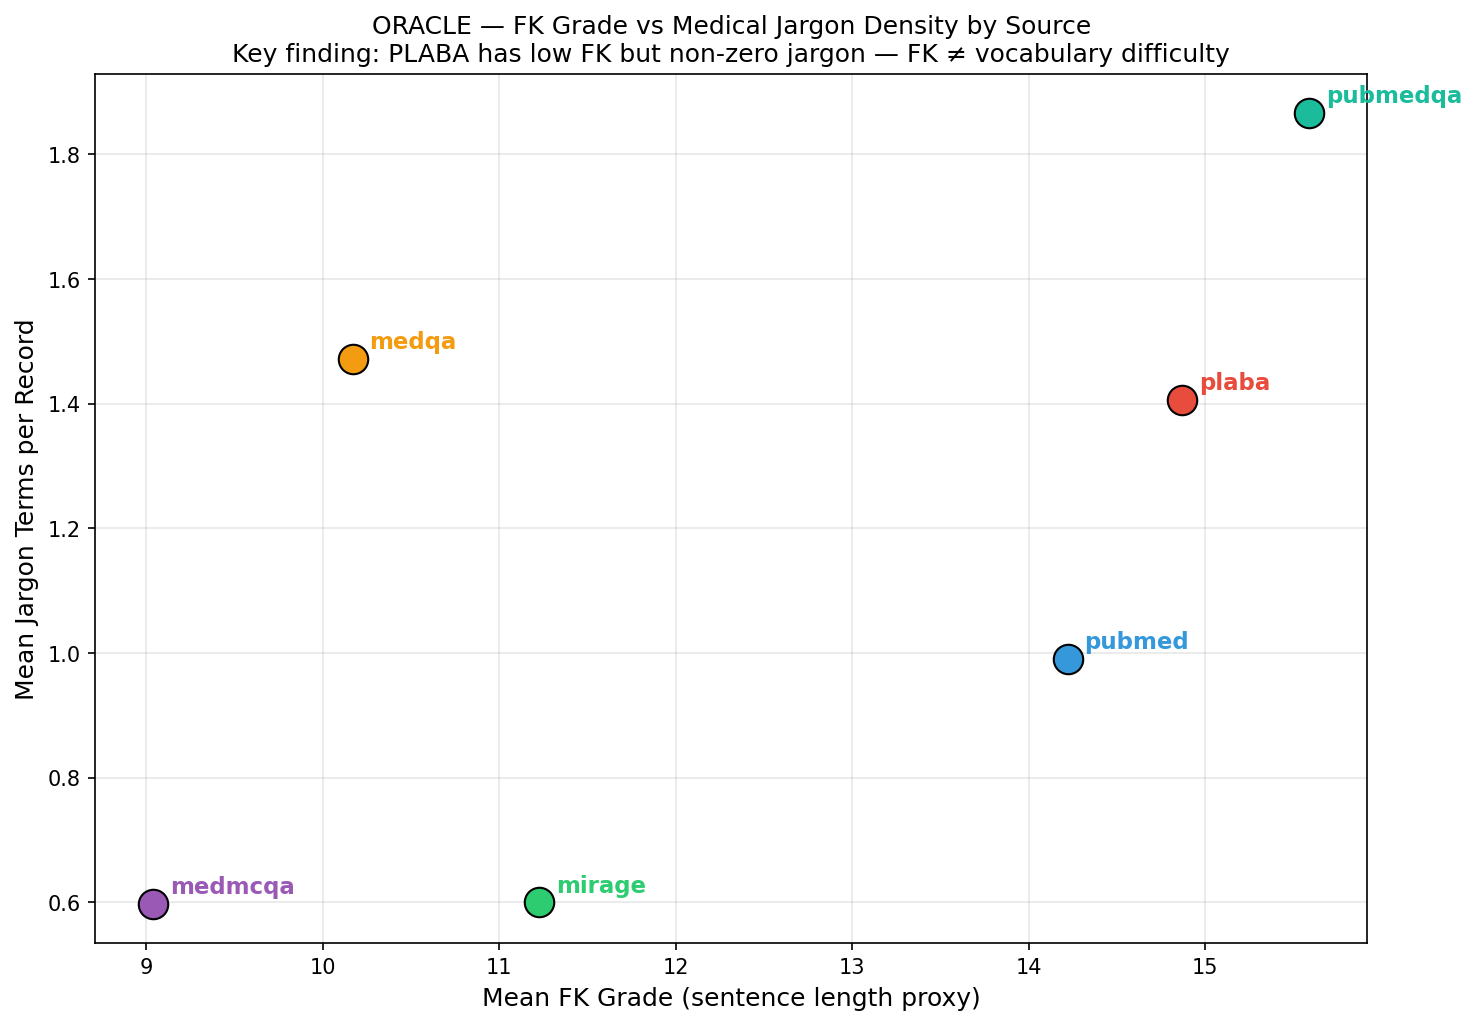

In [7]:
Image('../figures/stage3/jargon_fk_vs_jargon_scatter.png')

## 6. Key Findings

**1,491 unique medical terms** identified across corpus.

**Top jargon candidates for literacy_adapter.py expansion:**
- neurotoxicity (score=0.938) — purely clinical, zero low-band occurrences
- glycemia, ketosis, neurosis (score=0.857) — clinical metabolic/neurological
- carcinoma, edema, biopsy — high frequency, strong clinical bias

**FK vs jargon finding:**
PLABA has lower FK but non-zero jargon density — confirms FK measures sentence
length not vocabulary difficulty. Validates ORACLE Decision 11 FK proxy failure.

**Action:** Review jargon_candidates.csv top 50 entries.
Add highest-score terms to JARGON_SUBSTITUTIONS in literacy_adapter.py.